In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.io as sio
import timeit
import math
import random
import pickle
import matplotlib.lines as mlines
from scipy.sparse import csr_matrix
import scipy
from matplotlib.patches import Patch


# !pip install openpyxl

## Get data from sheet

In [3]:
df = pd.read_excel("data/SpineDataFinal.xlsx")
df["Area"] = df["Area"].str.strip().str.upper()

grouped = df.groupby(["Area", "Metric", "Age"]).agg(     # For each area, metric and age, takes the mean of the values we have 
    mean=("Value", "mean"))                              # For now, we treat apical, basal and total dendrites as the same

pivot_mean = grouped["mean"].unstack("Age")              # We turn it into a "Area+Metric vs Age" table

# Compute % change for both metrics together
pct = pivot_mean.groupby(level="Metric").apply(
    lambda x: x.sub(x["Y"], axis=0).div(x["Y"], axis=0)
)

numb_pct = pct.groupby(level="Area").mean()


## Extrapolate

In [4]:
area_spine = ['V1', 'V2', 'MT', 'LIP', 'V4', '7A' ,'7m', '8l', '8m', '5', 'TEO', 'DP', '2', 'F1', '7B', 'TEpd', '10', 'F5', '46d', 'PBr', '24c', 'F2', 'ProM', 'STPc', 'STPi', 'STPr', 'F7', '8b', '9/46v', '9/46d']
area_list = ['V1','V2','V4','DP','MT','8m','5','8l','2','TEO','F1','STPc','7A','46d','10','9/46v','9/46d','F5','TEpd','PBr','7m','LIP','F2','7B','ProM','STPi','F7','8b','STPr','24c']

def mapping(areas = area_spine):
    area_map = {
        "V1": ["V1"],

        "7A": ["7A"],

        "ACC": ["24c"],

        "LPFC": [
            "46d",
            "9/46v"
        ],

        "dlPFC": [
            "9/46d",
            '10'
        ]
    }

    reverse_map = {
        v: k
        for k, lst in area_map.items()
        for v in lst
    }


    numb_dict = numb_pct.to_dict(orient="index")

    Extrapolate = {}

    for area in areas:
        region = reverse_map.get(area, area)
        numb = numb_dict.get(region, { 'A': np.nan, 'M': np.nan, 'Y': np.nan })
        Extrapolate[area] = numb
        
    return Extrapolate

    # print(Extrapolate.keys())
Extr = mapping()
# Extr

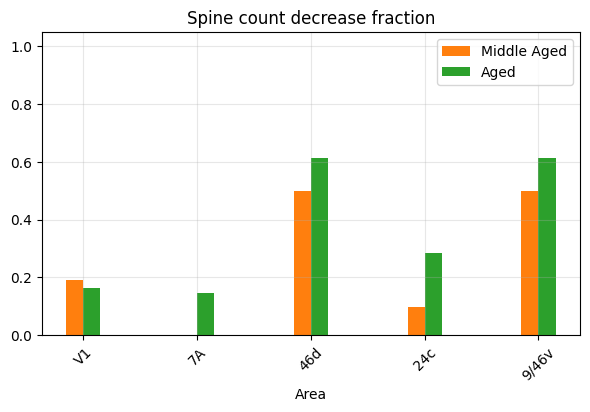

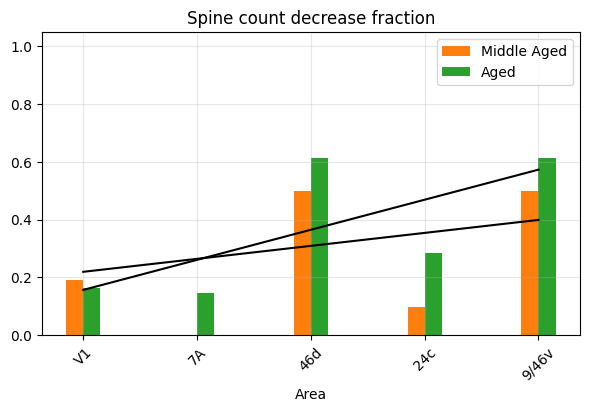

Average slope M: 0.045, Average Intercept M: 0.219
Average slope A: 0.104, Average Intercept A: 0.156


In [5]:
# Extrapolate
def plots(Extrapolate, lines=False):
    width = 0.15
    # x = np.arange(30)
    area_names = []
    fig, ax = plt.subplots(figsize=(6,4))
    cols = ['tab:blue', 'tab:orange','tab:green',]
    offsets = [-0.5*width, 0.5*width]

    avg_slope_A = []
    avg_int_A = []

    avg_slope_M = []
    avg_int_M = []

    numb_data = np.zeros((30,3))
    valid_mask = np.zeros(30, dtype=bool)
    for area,i in zip(Extrapolate.keys(), range(30)):
        temp = Extrapolate[area]
        if np.isnan(temp['M']) and np.isnan(temp['A']):
            continue
        numb_data[i,0] = temp['Y']
        numb_data[i,1] = temp['M']
        numb_data[i,2] = temp['A']
        area_names.append(area)
        valid_mask[i] = True

    x = np.arange(len(area_names))
    # ax.bar(x + offsets[0], numb_data[:,0], width, color=cols[0])
    numb_data = np.abs(numb_data[valid_mask])
    ax.bar(x + offsets[0], numb_data[:,1], width, color=cols[1], label='Middle Aged')
    ax.bar(x + offsets[1], numb_data[:,2], width, color=cols[2], label='Aged')

    if lines:
        for i in range(1,numb_data.shape[1]):
            y = numb_data[:,i]

            # Remove NaNs
            mask = ~np.isnan(y)
            x_clean = x[mask]
            y_clean = y[mask]

            # Linear regression
            if x_clean.shape[0] != 1:
                slope, intercept = np.polyfit(x_clean, y_clean, 1)
                # Print equation

                # print(f"Slope (m): {slope}, Intercept (b): {intercept}, Age = {['Young', 'Middle Aged', 'Aged'][i]}")
                if i==1:
                    avg_slope_M.append(slope)
                    avg_int_M.append(intercept)
                elif i==2:
                    avg_slope_A.append(slope)
                    avg_int_A.append(intercept)
                # Predicted values
                y_fit = slope * x_clean + intercept

                # Plot
                ax.plot(x_clean, y_fit, color='k')

    ax.set_xlabel('Area') # (ordered by spinecount)
    # ax.set_ylabel()
    ax.set_xticks(x)
    ax.set_xticklabels(area_names, rotation=45)

    ax.grid(alpha=0.3)
    plt.tight_layout()


    plt.legend()
    ax.set_ylim(0, 1.05)
    plt.title('Spine count decrease fraction')
    plt.savefig(f'Fig/Spine count decrease {lines}.svg', dpi=150, bbox_inches='tight')
    plt.show()
    if lines:
        print(f"Average slope M: {np.mean(avg_slope_M):.3f}, Average Intercept M: {np.mean(avg_int_M):.3f}")
        print(f"Average slope A: {np.mean(avg_slope_A):.3f}, Average Intercept A: {np.mean(avg_int_A):.3f}")
        
Extr = mapping()
plots(Extr)
plots(Extr, lines=True)

# Aging factors

In [6]:
labels = np.array(["Y", "MA", "A"])

# mask = (
#     df["Study"].str.strip().eq("Medalla & Luebke 2015") &
#     df["Area"].str.strip().str.upper().eq("V1")
# )

# df.loc[mask, "Value"] *= 1.1   # example adjustment

# factors to Y
to_Y = np.array([1.0, 1.15, 1.3])

# scaling matrix
scaling = to_Y[:, None] / to_Y[None, :]

# build full table with labels as first row and column
table = np.empty((len(labels) + 1, len(labels) + 1), dtype=object)

table[0, 0] = ""
table[0, 1:] = labels
table[1:, 0] = labels
table[1:, 1:] = scaling

# print(table)
print("\t" + "\t".join(labels))
for i, row in enumerate(scaling):
    print(labels[i] + "\t" + "\t".join(f"{x:.3f}" for x in row))
print(f"To go from 'row' i to 'column' j, we multiply by entry ij ")

	Y	MA	A
Y	1.000	0.870	0.769
MA	1.150	1.000	0.885
A	1.300	1.130	1.000
To go from 'row' i to 'column' j, we multiply by entry ij 
